In [26]:
import astropy.units as au
import jax
import jax.numpy as jnp
import numpy as np
from astropy.io import fits

from dsa2000_cal.solvers.multi_step_lm import lm_solver
from dsa2000_common.common.fits_utils import haversine
from dsa2000_common.delay_models.uvw_utils import perley_icrs_from_lmn


# Opens some PSFs from FITS files, then bins the PSF as a function of radius, and fits psf(r, duration) = A * duration^alpha(r) where duration is the time synthesis of PSF. We add back autocorrelation to the PSF first

@jax.jit
def fit(psf_values, durations):
    def residuals(params, psf_values, durations):
        A, alpha = params
        return 10 * jnp.log10(psf_values) - A - alpha * jnp.log10(durations)

    (A, alpha), diagnostics = lm_solver(
        residuals, (10 * jnp.log10(jnp.mean(psf_values)), jnp.array(0.)),
        args=(psf_values, durations),
        verbose=False
    )
    return A, alpha


def fit_radial_psf(psfs, radii, durations, r_bins, q=50):
    # Get the quantile in each bin and fit the model
    measurements = []
    As = []
    alphas = []
    for i in range(len(r_bins) - 1):
        _measurements = []
        _durations = []
        for psf, radius, dur in zip(psfs, radii, durations):
            mask = (radius >= r_bins[i]) & (radius < r_bins[i + 1])
            samples = psf[mask]
            _measurements.append(np.percentile(samples, q))
            _durations.append(dur)
        # fit with curve_fit
        A, alpha = fit(np.array(_measurements), np.array(_durations))
        print(_measurements, durations)
        print(f"R=[{r_bins[i]}, {r_bins[i + 1]}]: A={A:.3f}, alpha={alpha:.3f}")
        alphas.append(alpha)
        As.append(A)
        measurements.append(_measurements)
    measurements = jnp.array(measurements)
    return As, alphas, measurements

import glob

# psf_files = glob.glob('psf_*min_16_500chan_natural/*/*_psf.fits')
# psf_files = [
#     'psf_dec0.0_28min_16_500chan_natural/dsa1650_P305_v2.4.6/dsa1650_P305_v2.4.6_psf.fits',
#     'psf_dec0.0_35min_16_500chan_natural/dsa1650_P305_v2.4.6/dsa1650_P305_v2.4.6_psf.fits',
#     'psf_dec0.0_14min_16_500chan_natural/dsa1650_P305_v2.4.6/dsa1650_P305_v2.4.6_psf.fits',
#     'psf_dec0.0_42min_16_500chan_natural/dsa1650_P305_v2.4.6/dsa1650_P305_v2.4.6_psf.fits',
#     'psf_dec0.0_7min_16_500chan_natural/dsa1650_P305_v2.4.6/dsa1650_P305_v2.4.6_psf.fits',
#     'psf_dec0.0_49min_16_500chan_natural/dsa1650_P305_v2.4.6/dsa1650_P305_v2.4.6_psf.fits',
#     'psf_dec0.0_21min_16_500chan_natural/dsa1650_P305_v2.4.6/dsa1650_P305_v2.4.6_psf.fits'
# ]
# print(psf_files)
# durations = [
#     28,35,14,42,7,49,21
# ]


psf_files = [
    './skamid_b1_1000h_dsa1650_a_P305_v2.4.6_psf.fits',
    './skamid_b1_1000h_dsa1650_a_P305_v2.4.6_psf.fits',
]
durations = [
    7.,
    28.
]
# open and get pixel sizes, then compute lmn, then get refernce PSF ra,dec and convert each lmn to ra,dec

In [27]:

psfs = []
radii = []
radii_haversine = []
for psf_file in psf_files:
    with fits.open(psf_file) as hdul:
        psf = hdul[0].data.T[::-1, :, 0, 0]
        header = hdul[0].header
        dl = abs(au.Quantity(header['CDELT1'], header['CUNIT1']))
        dm = au.Quantity(header['CDELT2'], header['CUNIT2'])
        ra0 = au.Quantity(header['CRVAL1'], header['CUNIT1']).to('rad').value
        dec0 = au.Quantity(header['CRVAL2'], header['CUNIT2']).to('rad').value
        num_l, num_m = psf.shape
        lvec = (-0.5 * num_l + np.arange(num_l)) * dl.to('rad').value
        mvec = (-0.5 * num_m + np.arange(num_m)) * dm.to('rad').value
        L, M = np.meshgrid(lvec, mvec, indexing='ij')
        N = np.sqrt(1 - L ** 2 - M ** 2)

        ra, dec = perley_icrs_from_lmn(L, M, N, ra0, dec0)
        # get great circle distance from ra, dec to ra0, dec0
        radius = np.sqrt(L**2 + M**2)
        radii_haversine.append(haversine(ra, dec, ra0, dec0))
        psfs.append(psf)
        radii.append(radius)

psfs[1] *=0.99

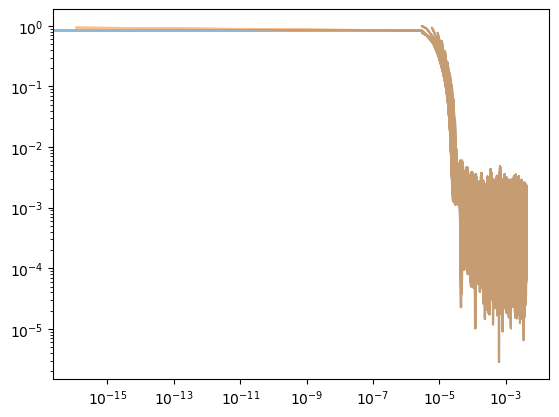

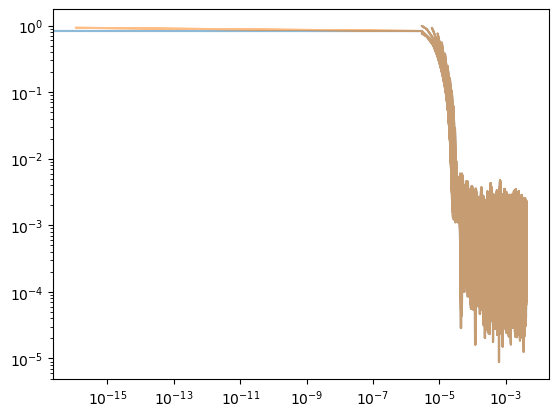

In [28]:

# plot
import pylab as plt
n = 1650
def transform_to_total_power(psf):
    return (psf + 1/(n-1)) * (n-1) / n

r_bins = np.linspace(0., radii[0].max(), 10)


for psf, radius,radius_haversine, duration in zip(psfs, radii, radii_haversine, durations):
    plt.plot(radius.flatten(), transform_to_total_power(psf.flatten()), alpha=0.5)
    plt.plot(radius_haversine.flatten(), transform_to_total_power(psf.flatten()),alpha=0.5)

    rbins = np.linspace(0, radius.max(), 100)

    plt.xscale('log')
    plt.yscale('log')
    plt.show()
    # plt.hist(radius.flatten(), weights=psf.flatten(), bins=50, alpha=0.1)
    # im = plt.imshow(10*np.log10(transform_to_total_power(psf).T), origin='lower',cmap='jet')
    # plt.colorbar(im)



In [29]:

r_bins = np.linspace(0., radii[0].max(), 1000)
r_center = (r_bins[:-1] + r_bins[1:]) / 2

As, alphas, measurements = fit_radial_psf(
    [transform_to_total_power(psf) for psf in psfs],
    radii,
    durations,
    r_bins=r_bins,
    q=50
)


[0.8380520157380538, 0.8296775561867338] [7.0, 28.0]
R=[0.0, 4.2445178014159096e-06]: A=-0.706, alpha=-0.007
[0.6038397612535593, 0.5978074242470842] [7.0, 28.0]
R=[4.2445178014159096e-06, 8.489035602831819e-06]: A=-2.130, alpha=-0.007
[0.3252904482863166, 0.3220436044095141] [7.0, 28.0]
R=[8.489035602831819e-06, 1.2733553404247729e-05]: A=-4.816, alpha=-0.007
[0.15852010187326054, 0.15694096146058856] [7.0, 28.0]
R=[1.2733553404247729e-05, 1.6978071205663638e-05]: A=-7.938, alpha=-0.007
[0.06558590863916007, 0.06493611015882908] [7.0, 28.0]
R=[1.6978071205663638e-05, 2.1222589007079548e-05]: A=-11.771, alpha=-0.007
[0.016170763138004328, 0.016015116112684892] [7.0, 28.0]
R=[2.1222589007079548e-05, 2.5467106808495457e-05]: A=-17.854, alpha=-0.007
[0.0026023109840708925, 0.0025823484802907897] [7.0, 28.0]
R=[2.5467106808495457e-05, 2.9711624609911367e-05]: A=-25.799, alpha=-0.006
[0.0037026552311285876, 0.0036716892848779074] [7.0, 28.0]
R=[2.9711624609911367e-05, 3.3956142411327276e-05

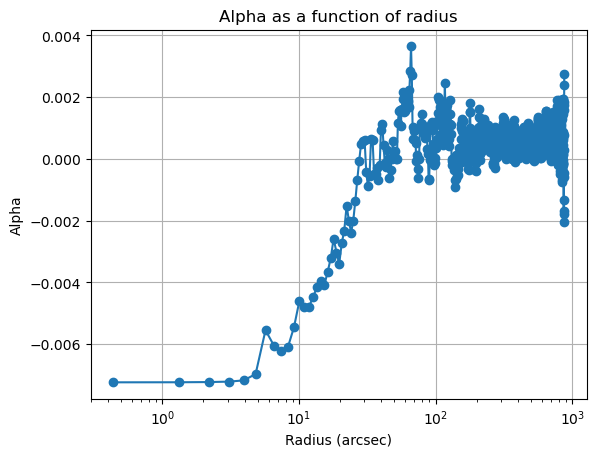

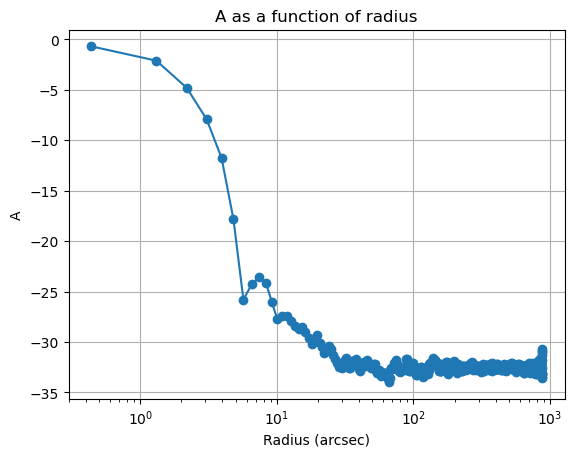

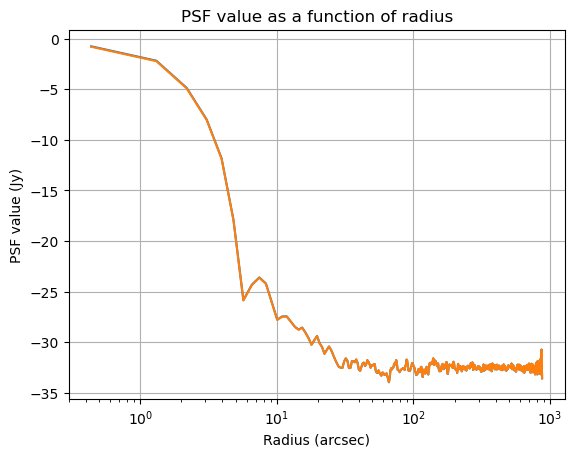

In [30]:


plt.figure()
plt.plot(r_center * 180 * 3600 / np.pi, alphas, marker='o')
plt.xlabel("Radius (arcsec)")
plt.ylabel("Alpha")
plt.title("Alpha as a function of radius")
plt.xscale('log')
plt.grid()
plt.show()

plt.figure()
plt.plot(r_center * 180 * 3600 / np.pi, As, marker='o')
plt.xlabel("Radius (arcsec)")
plt.ylabel("A")
plt.title("A as a function of radius")
plt.xscale('log')
plt.grid()
plt.show()

plt.figure()
plt.plot(r_center * 180 * 3600 / np.pi, 10*np.log10(measurements))
plt.xlabel("Radius (arcsec)")
plt.ylabel("PSF value (Jy)")
plt.title("PSF value as a function of radius")
plt.xscale('log')
plt.grid()
plt.show()


